## Creating the final features for model training.

In [1]:
# importing required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [2]:
# extract data
input_file_path = '../data/raw/train_data.csv'
df = pd.read_csv(input_file_path)
df['SalesDate'] = pd.to_datetime(df['SalesDate'])

In [3]:
# Product specific metric for Product Mix Analysis
product_metrics = df.groupby('ProductID').agg(
    TotalSalesPrice=('ExtPrice', 'sum'),
    TotalCost=('ExtCost', 'sum'),
    TotalProfit=('Profit', 'sum'),
    AvgUnitPrice=('UnitPrice', 'mean'),
    AvgUnitCost=('UnitCost', 'mean'),
    TotalSalesQty=('SalesQty', 'sum'),
    TotalOrders=('OrderNumber', 'nunique'),
    UniqueCustomers=('CustomerName', 'nunique'),
    PriceVolatility=('UnitPrice', 'std')
).reset_index()

In [4]:
# Compute Additional Metrics
product_metrics['ProfitMargin'] = product_metrics['TotalProfit'] / product_metrics['TotalSalesPrice']
product_metrics['AvgOrderSize'] = product_metrics['TotalSalesQty'] / product_metrics['TotalOrders']
product_metrics['RepeatPurchaseRatio'] = product_metrics['TotalOrders'] / product_metrics['UniqueCustomers']


In [5]:
# Check Correlation with Profit
correlation = product_metrics.drop(columns=['ProductID']).corr()['TotalSalesPrice'].sort_values(ascending=False)
print("\nCorrelation with TotalSalesPrice:\n", correlation)


Correlation with TotalSalesPrice:
 TotalSalesPrice        1.000000
TotalCost              0.976203
TotalProfit            0.863749
TotalOrders            0.480225
TotalSalesQty          0.359907
RepeatPurchaseRatio    0.343778
AvgOrderSize           0.095400
UniqueCustomers        0.082478
PriceVolatility        0.055813
AvgUnitCost            0.035694
AvgUnitPrice           0.027990
ProfitMargin           0.001686
Name: TotalSalesPrice, dtype: float64


In [6]:
# Identify Customers Who Bought Each Product
product_customers = df.groupby('ProductID')['CustomerName'].unique().reset_index()
product_customers['CustomerCount'] = product_customers['CustomerName'].apply(len)

In [7]:
# Merge Customer Data
product_metrics = product_metrics.merge(product_customers[['ProductID', 'CustomerCount']], on='ProductID', how='left')

In [8]:
# Display Final Product Metrics DataFrame
print(product_metrics[['ProductID', 'TotalSalesPrice', 'TotalProfit', 'TotalSalesQty','CustomerCount']].sort_values(by='CustomerCount', ascending=False).head())

         ProductID  TotalSalesPrice  TotalProfit  TotalSalesQty  CustomerCount
23301  RZS-746-II7         15019.77      8636.21         385699             79
27628  VHP-115-RC8          8865.05      4144.06         114908             63
8500   GOB-744-MF6          5990.26      3125.35          41536             56
2877   CER-058-JV8          6525.63      3604.03          56922             54
12953  JZY-494-CR7        182168.94     36886.42           4272             53


In [9]:
df.columns

Index(['Unnamed: 0', 'BranchName', 'Ship2City', 'Ship2State', 'OrderNumber',
       'InvoiceNumber', 'LineNumber', 'OrderDate', 'SalesDate',
       'SalesPersonID', 'SalesPersonName', 'ProductID', 'ProductGroupID',
       'CustomerID', 'CustomerName', 'ExtPrice', 'ExtCost', 'SalesQty',
       'UnitPrice', 'UnitCost', 'UOM', 'UnitSize', 'Month', 'Year', 'Profit',
       'ProfitMargin', 'ProfitCost_Ratio', 'customer_alias'],
      dtype='object')

In [10]:
# Calculate customer lifetime (duration between first and last purchase)
customer_lifetime = df.groupby("CustomerName").agg(
    FirstPurchase=("SalesDate", "min"),
    LastPurchase=("SalesDate", "max")
).reset_index()

# Compute lifetime in days
customer_lifetime["CustomerLifetimeDays"] = (customer_lifetime["LastPurchase"] - customer_lifetime["FirstPurchase"]).dt.days

# Merge with customer_metrics
customer_metrics = df.groupby("CustomerName").agg(
    TotalRevenue=("ExtPrice", "sum"), # total revenue generated by the customer
    TotalProfit=("Profit", "sum"), # total profit generated by the customer
    TotalUnitPrice=("UnitPrice", "sum"), # total individual unit price for all purchases by the customer
    TotalSalesQty=("SalesQty", "sum"), # total quantity sold to the customer
    OrderCount=("OrderNumber", "nunique"), # total number of orders placed by the customer
    NumDistinctProducts=("ProductID", "nunique"), # number of distinct products purchased by the customer
    NumDistinctProductGroups=("ProductGroupID", "nunique"), # number of distinct product groups purchased by the customer
    BranchCount=("BranchName", "nunique"), # number of branches visited by the customer
    TopProductID=("ProductID", lambda x: x.value_counts().idxmax()), # most popular product purchased by the customer
    TopProductGroupID=("ProductGroupID", lambda x: x.value_counts().idxmax()), # most popular product group purchased by the customer
    ProductDiversityIndex=("ProductID", lambda x: len(x.unique()) / x.count()), # number of distinct products divided by the total sales quantity
    ProductConcentrationIndex=("ExtPrice", lambda x: x.max() / x.sum()), # revenue of the most expensive product divided by the total revenue
    TopProductRevenueShare=("ExtPrice", lambda x: x.groupby(df["ProductID"]).sum().max() / x.sum()), # revenue share of the most expensive product
    TopProductGroupRevenueShare=("ExtPrice", lambda x: x.groupby(df["ProductGroupID"]).sum().max() / x.sum()) # revenue share of the most expensive product group
).reset_index()

customer_metrics = customer_metrics.merge(customer_lifetime[["CustomerName", "CustomerLifetimeDays"]], on="CustomerName", how="left")

In [11]:
# Compute additional features
customer_metrics['AvgOrderValue'] = customer_metrics['TotalRevenue'] / customer_metrics['OrderCount'] # average order value
customer_metrics['RepeatPurchaseRatio'] = customer_metrics['OrderCount'] / customer_metrics['NumDistinctProducts'] # raio of number of orders and number of distinct products bought

# Merge with Product-Level Profitability Metrics
product_profit = product_metrics[['ProductID', 'TotalProfit']]
df = df.merge(product_profit, on='ProductID', how='left')

# Identify High-Profit and Popular Products
high_profit_threshold = product_metrics['TotalProfit'].quantile(0.75)  # Top 25% most profitable
popular_product_threshold = product_metrics['TotalSalesQty'].quantile(0.75)  # Top 25% most sold

df['HighProfitProduct'] = df['Profit'] >= high_profit_threshold # Top 25% most profitable
df['PopularProduct'] = df['SalesQty'] >= popular_product_threshold # Top 25% most sold

# Compute Customer Engagement with High-Profit & Popular Products
customer_product_engagement = df.groupby('CustomerName').agg(
    HighProfitProductShare=('HighProfitProduct', 'mean'), # percentage of orders with high-profit products
    PopularProductShare=('PopularProduct', 'mean'), # percentage of orders with popular products
    HighProfitOrderRatio=('HighProfitProduct', 'sum'), # number of orders with high-profit products
    PopularOrderRatio=('PopularProduct', 'sum') # number of orders with popular products
).reset_index()

# Merge into customer dataset
customer_metrics = customer_metrics.merge(customer_product_engagement, on='CustomerName', how='left')


In [12]:
customer_metrics.head(1)

,CustomerName,TotalRevenue,TotalProfit,TotalUnitPrice,TotalSalesQty,OrderCount,NumDistinctProducts,NumDistinctProductGroups,BranchCount,TopProductID,...,ProductConcentrationIndex,TopProductRevenueShare,TopProductGroupRevenueShare,CustomerLifetimeDays,AvgOrderValue,RepeatPurchaseRatio,HighProfitProductShare,PopularProductShare,HighProfitOrderRatio,PopularOrderRatio
0,ADAMS PLC AND SONS,59976.78,25827.38,5183.51485,150624,44,125,17,2,KGX-452-TJ2,...,0.041316,0.165861,0.215245,169,1363.108636,0.352,0.039867,0.17608,12,53


Outliers have been found by running a simple k-means model to categorize the customers

In [13]:

# Outliers from data exploration
diamond_plus_customers = customer_metrics[customer_metrics["CustomerName"].isin(["BURKE AND SONS AND SONS", "ROBERTS LLC GROUP"])]


Add code to test feature correlation

In [14]:

# excluding Total Revenue from features
# commented out other feature after testing
features = [ 
    "TotalProfit", 
    "TotalUnitPrice", 
    "TotalSalesQty", 
    "OrderCount",  
    "NumDistinctProducts", 
    "NumDistinctProductGroups", 
    "BranchCount",
    "HighProfitOrderRatio", 
    "PopularOrderRatio",
    # "ProductDiversityIndex", 
    # "ProductConcentrationIndex", 
    # "TopProductRevenueShare", 
    # "TopProductGroupRevenueShare", 
    "CustomerLifetimeDays", 
    # "AvgOrderValue", 
    "RepeatPurchaseRatio", 
    "HighProfitProductShare", 
    "PopularProductShare"
    ]
X = customer_metrics[features]
Y = customer_metrics["TotalRevenue"]

In [15]:

correlation = X.corrwith(Y)
print(correlation)
feature_correlation = pd.DataFrame(correlation, columns=["Correlation"])


TotalProfit                 0.981288
TotalUnitPrice              0.672040
TotalSalesQty               0.905891
OrderCount                  0.865257
NumDistinctProducts         0.559003
NumDistinctProductGroups    0.445238
BranchCount                 0.137157
HighProfitOrderRatio        0.898557
PopularOrderRatio           0.854142
CustomerLifetimeDays        0.152899
RepeatPurchaseRatio         0.179669
HighProfitProductShare     -0.011462
PopularProductShare         0.088772
dtype: float64


In [16]:
rf = RandomForestRegressor(n_estimators=100, random_state=42) 

In [17]:
rf.fit(X, Y)

RandomForestRegressor(random_state=42)

In [18]:
accuracy = rf.score(X, Y)
feature_importance = pd.DataFrame(rf.feature_importances_, index=X.columns, columns=["Importance"]).sort_values("Importance", ascending=False)
print(feature_importance.sort_values("Importance", ascending=False))
print(f'\nAccuracy using Random Forest model: {accuracy:.2f}')

                          Importance
TotalProfit                 0.546559
TotalSalesQty               0.195087
PopularOrderRatio           0.110080
HighProfitOrderRatio        0.058814
OrderCount                  0.029601
TotalUnitPrice              0.021067
PopularProductShare         0.020151
HighProfitProductShare      0.007666
NumDistinctProducts         0.004742
RepeatPurchaseRatio         0.002297
NumDistinctProductGroups    0.002157
CustomerLifetimeDays        0.001561
BranchCount                 0.000218

Accuracy using Random Forest model: 0.99


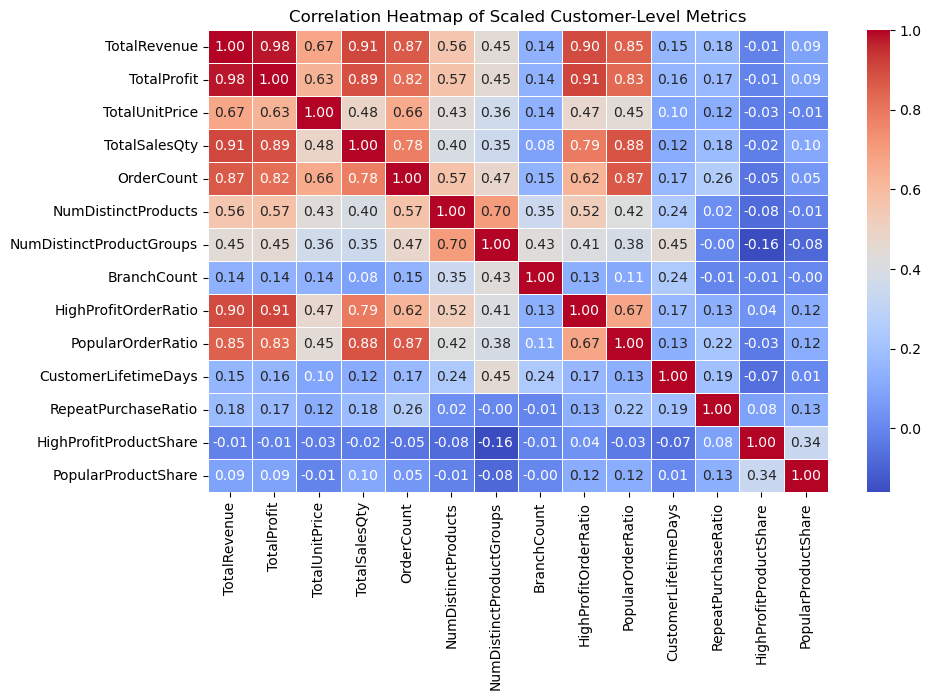

In [19]:
# Standardize features before checking correlation
scaler = StandardScaler()
features = ["TotalRevenue"]+ features
scaled_features = scaler.fit_transform(customer_metrics[features])

# Create a DataFrame with the scaled features
scaled_customer_metrics = pd.DataFrame(scaled_features, columns=features)

# Generate correlation heatmap for scaled customer-level data
scaled_customer_corr_matrix = scaled_customer_metrics.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(scaled_customer_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Scaled Customer-Level Metrics")
plt.show()

Saving all the final features to pick best for model training

In [20]:
# Create directories if they do not exist
output_dir = '../data/cleaned'
os.makedirs(output_dir, exist_ok=True)

# Export customer_metrics to CSV
customer_metrics.to_csv(os.path.join(output_dir, 'customer_metrics_with_product_related_features.csv'), index=False)

Checking branch information

In [21]:
customer_metrics["BranchCount"].value_counts()

BranchCount
1    820
2    158
3     17
5      2
6      1
4      1
Name: count, dtype: int64

In [22]:
# Group by BranchCount and calculate the average TotalProfit and TotalRevenue
branch_profit_revenue = customer_metrics.groupby('BranchCount').agg(
    AvgTotalProfit=('TotalProfit', 'mean'),
    AvgTotalRevenue=('TotalRevenue', 'mean')
).reset_index()

print(branch_profit_revenue)

   BranchCount  AvgTotalProfit  AvgTotalRevenue
0            1    29279.239838     99603.008463
1            2   117129.214178    383996.031456
2            3   265174.113112    867283.814118
3            4     6222.109000    647562.960000
4            5    78109.295000    340945.465000
5            6   316534.870000    726424.850000
